In [2]:
#install sklearn on the spot
!pip install scikit-learn
!pip install statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_FILEPATH_P2 = '../MAIN/dataset_clean_encoded_p2.csv'
data = pd.read_csv(DATA_FILEPATH_P2)
print("Verify shape of data after loading from csv, should have had 6 outlier rows removed from part 1:")
print(data.shape)

Verify shape of data after loading from csv, should have had 6 outlier rows removed from part 1:
(302, 15)


In [277]:
# function for quick-plotting graphs of numerical variables
def plot_relevant_visualisations(column_name,df,modifier = '',kind='line',log=False,box = True):
    
    #log affects the number of plots, and associated variables.
    num_plots = 3 if not log else 4
    SCALE_FACTOR = 5
    fig,axes = plt.subplots(1,num_plots,figsize=((SCALE_FACTOR+1)*num_plots,SCALE_FACTOR))
    
    if not log:
        ax_hist,ax_line, ax_box= axes
    else:
        ax_hist,ax_line,ax_box,ax_log = axes
    
    freq, bins, patches = ax_hist.hist(df[column_name],bins=20,edgecolor='white')
    
    bin_centers = np.diff(bins)*0.5 + bins[:-1]

    n = 0
    for fr, x, patch in zip(freq, bin_centers, patches):
        height = int(freq[n])
        ax_hist.annotate("{}".format(height),
                    xy = (x, height),             # top left corner of the histogram bar
                    xytext = (0,0.2),             # offsetting label position above its bar
                    textcoords = "offset points", # Offset (in points) from the *xy* value
                    ha = 'center', va = 'bottom'
                    )
        n = n+1
    
    ax_hist.set_title(f"Distribution of {column_name} \n (with labelled frequencies)", fontsize=10)
    ax_hist.set_xlabel(column_name, fontsize=10)
    ax_hist.set_ylabel("Frequency", fontsize=10)
    
    if kind == 'line':
        ax_line.plot(df['continuous_months'],df[column_name],color='orange')
    else:
        ax_line.scatter(df['continuous_months'],df[column_name],color='orange')
    
    ax_line.set_title(f"{column_name} levels over time", fontsize=12)
    ax_line.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: str(int(x//12))))
    ax_line.set_xlabel('Year', fontsize=10)
    ax_line.set_ylabel(column_name, fontsize=10)
    
    df[column_name].plot(ax=ax_box,kind='box')
    ax_box.set_xlabel(column_name, fontsize=10)
    ax_box.set_ylabel('values', fontsize=10)
    ax_box.set_title(f'box plot of {column_name} ', fontsize=10)
    
    if log:
        logdf = df[column_name].copy().apply(np.log)
        new_skew = logdf.skew()
        
        lfreq, lbins, lpatches = ax_log.hist(logdf,bins=20,edgecolor='white',color='green')
        
        lbin_centers = np.diff(lbins)*0.5 + lbins[:-1]

        n = 0
        for fr, lx, patch in zip(lfreq, lbin_centers, lpatches):
            lheight = int(lfreq[n])
            ax_log.annotate("{}".format(lheight),
                        xy = (lx, lheight),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            n = n+1
        
        ax_log.set_title(f"Distribution after log_transformation \n of {column_name} (new skew: {new_skew:.2f})", fontsize=10)
        ax_log.set_xlabel(column_name, fontsize=10)
        ax_log.set_ylabel("Frequency", fontsize=10)
    
    plt.show()

In [278]:
# function for quick-plotting graphs of categorical variables
def plot_categorical(column_name,df,modifier = '',kind='line',log=False,box = True):
    
    #log affects the number of plots, and associated variables.
    num_plots = 2 if not log else 3
    SCALE_FACTOR = 5
    fig,axes = plt.subplots(1,num_plots,figsize=((SCALE_FACTOR+1)*num_plots,SCALE_FACTOR))
    
    if not log:
        ax_hist,ax_line= axes
    else:
        ax_hist,ax_line,ax_log = axes
    

    df.groupby(column_name)[column_name].value_counts().plot.bar(ax=ax_hist)
    
    ax_hist.set_title(f"Distribution of {column_name} \n (with labelled frequencies)", fontsize=10)
    ax_hist.set_xlabel(column_name, fontsize=10)
    ax_hist.set_ylabel("Frequency", fontsize=10)
    
    if kind == 'line':
        ax_line.plot(df['continuous_months'],df[column_name+'_ord'],color='orange')
    else:
        ax_line.scatter(df['continuous_months'],df[column_name+'_ord'],color='orange')
    
    ax_line.set_title(f"{column_name} levels over time", fontsize=12)
    ax_line.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: str(int(x//12))))
    ax_line.set_xlabel('Year', fontsize=10)
    ax_line.set_ylabel(column_name, fontsize=10)
    
    
    if log:
        logdf = df[column_name].copy().apply(np.log)
        new_skew = logdf.skew()
        
        lfreq, lbins, lpatches = ax_log.hist(logdf,bins=20,edgecolor='white',color='green')
        
        lbin_centers = np.diff(lbins)*0.5 + lbins[:-1]

        n = 0
        for fr, lx, patch in zip(lfreq, lbin_centers, lpatches):
            lheight = int(lfreq[n])
            ax_log.annotate("{}".format(lheight),
                        xy = (lx, lheight),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            n = n+1
        
        ax_log.set_title(f"Distribution after log_transformation \n of {column_name} (new skew: {new_skew:.2f})", fontsize=10)
        ax_log.set_xlabel(column_name, fontsize=10)
        ax_log.set_ylabel("Frequency", fontsize=10)
    
    plt.show()

In [279]:
# function for seeing how well moving averages are
def plot_MA_goodness(cont_var,MA_var,data):
    #data[cont_var].plot(label=cont_var,figsize=(20,10),color='orange')
    #data[MA_var].plot(label=MA_var,figsize=(20,10),color='blue')
    data[cont_var].plot(label=cont_var,color='orange')
    data[MA_var].plot(label=MA_var,color='blue')
    plt.legend(loc='best')
    # Add vertical lines at each year change
    year_changes = data['Year'].diff() > 0
    for idx in data[year_changes].index:
        plt.axvline(x=idx, color='gray', linestyle='--', alpha=0.5)
        #plt.text(idx, plt.ylim()[1]*0.95, str(data.loc[idx, 'Year']), 
        #         rotation=90, verticalalignment='top', alpha=0.7)
    plt.show()

In [281]:
from sklearn.preprocessing import StandardScaler

#data['Temp'].plot(kind='line',figsize=(20,10),color='orange')
"""
data['Temp_diff_st'].plot(kind='line')

data['MEI_CO2'] = data['MEI'] + data['CO2_diff']
data['MEI_CO2_st'] = StandardScaler().fit_transform(data[['MEI_CO2']])
data['MEI_CO2_st'].plot(kind='line',alpha = 0.5)

plt.legend(loc='best')
plt.show()
"""

"\ndata['Temp_diff_st'].plot(kind='line')\n\ndata['MEI_CO2'] = data['MEI'] + data['CO2_diff']\ndata['MEI_CO2_st'] = StandardScaler().fit_transform(data[['MEI_CO2']])\ndata['MEI_CO2_st'].plot(kind='line',alpha = 0.5)\n\nplt.legend(loc='best')\nplt.show()\n"

added moving average and difference from moving average from time series data (`CO2`, `MEI`, `CH4`)

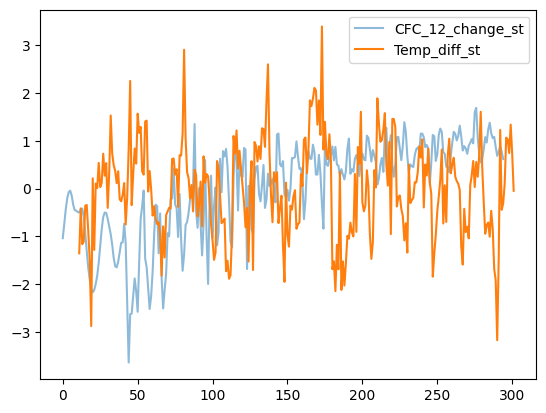

In [ ]:
# test variables before adding
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler

# get CH4 Moving average over each year and get the difference
data['CFC_12_MA'] = data['CFC-12'].rolling(window=12).mean()
data['CFC_12_diff'] = data['CFC-12'] - data['CFC_12_MA']
data['CFC_12_diff_st'] = StandardScaler().fit_transform(data[['CFC_12_diff']])
data['CFC_12_diff_st_z'] = data['CFC_12_diff_st'].apply(lambda x: np.abs(x) < 3)

data['CFC_12_change'] = data['CFC-12'].diff()
data['CFC_12_change'] = data['CFC_12_change'].shift(-7)
data['CFC_12_change_st'] = StandardScaler().fit_transform(data[['CFC_12_change']])
data['CFC_12_change_st'] = -data['CFC_12_change_st']
#data['CFC_12_change_st'].plot(kind='line', alpha = 0.5)
#data['CFC_12_diff_st'].plot(kind='line', alpha = 0.5)


data['Temp_MA'] = data['Temp'].rolling(window=12).mean()
data['Temp_diff'] = data['Temp'] - data['Temp_MA']
data['Temp_diff_st'] = StandardScaler().fit_transform(data[['Temp_diff']])
#data['Temp_diff_st'].plot(kind='line')

data.loc[:,~data.columns.duplicated()]
plt.legend(loc='best')
plt.show()
#data.sample(12)

best shift wrt MSE

In [ ]:
from sklearn.metrics import mean_squared_error

# Define the range of shift values to test
shift_range = range(-12, 13)  # Example: test shifts from -12 to +12 months
best_shift = None
min_mse = float('inf')

# Iterate over the shift range
for shift in shift_range:
    # Apply the shift to Temp_diff
    data['CH4_MA'] = data['CH4'].rolling(window=12).mean()
    data['CH4_diff'] = data['CH4'] - data['CH4_MA']
    data['CFC_diff_shifted'] = data['CH4_diff'].shift(shift)
    data['CH4_diff_st'] = StandardScaler().fit_transform(data[['CFC_diff_shifted']])
    mse_arr = data.copy()
    mse_arr = mse_arr.dropna()
    # Calculate MSE between Temp_diff_st_z and Temp_diff_st
    mse = mean_squared_error(mse_arr['Temp_diff_st'], mse_arr['CH4_diff_st'])
    
    # Update the best shift if the current MSE is smaller
    if mse < min_mse:
        min_mse = mse
        best_shift = shift

print(f"Best shift: {best_shift}, Minimum MSE: {min_mse}")

best_shift = None
min_mse = float('inf')
for shift in shift_range:
    # Apply the shift to Temp_diff
    data['CH4_change'] = data['CH4'].diff()
    data['CH4_change_shifted'] = data['CH4_change'].shift(shift)
    data['CH4_change_st'] = StandardScaler().fit_transform(data[['CH4_change_shifted']])
    #data['CH4_change_st'] = -data['CH4_diff_st']
    mse_arr = data.copy()
    mse_arr = mse_arr.dropna()
    #print(mse_arr.isnull().sum())
    # Calculate MSE between Temp_diff_st_z and Temp_diff_st
    mse = mean_squared_error(mse_arr['Temp_diff_st'], mse_arr['CH4_change_st'])
    
    # Update the best shift if the current MSE is smaller
    if mse < min_mse:
        min_mse = mse
        best_shift = shift

print(f"Best shift: {best_shift}, Minimum MSE: {min_mse}")


Best shift: -8, Minimum MSE: 1.6367243585055389
Best shift: -7, Minimum MSE: 1.6622882599554312


In [287]:
from sklearn.preprocessing import StandardScaler

# get standardised difference in global temperature from moving average
data['Temp_MA'] = data['Temp'].rolling(window=12).mean()
data['Temp_diff'] = data['Temp'] - data['Temp_MA']
data['Temp_diff_st'] = StandardScaler().fit_transform(data[['Temp_diff']])

# get change in CO2 from Moving average over each year and get the difference
data['CO2_MA'] = data['CO2'].rolling(window=12).mean()
data['CO2_diff'] = data['CO2'] - data['CO2_MA']
data['CO2_diff'] = data['CO2_diff'].shift(-5)
data['CO2_diff_st'] = StandardScaler().fit_transform(data[['CO2_diff']])
data['CO2_diff_st_z'] = data['CO2_diff_st'].apply(lambda x: np.abs(x) < 3)
data.drop(data[data['CO2_diff_st_z']==False].index)

# get CH4 Moving average over each year and get the difference
data['CH4_MA'] = data['CH4'].rolling(window=12).mean()
data['CH4_diff'] = data['CH4'] - data['CH4_MA']
data['CH4_diff_st'] = StandardScaler().fit_transform(data[['CH4_diff']])
data['CH4_diff_st'] = data['CH4_diff_st'].shift(-8)
data['CH4_diff_st_z'] = data['CH4_diff_st'].apply(lambda x: np.abs(x) < 3)
data.drop(data[data['CH4_diff_st_z']==False].index)

# get MEI diff from moving average 
#data['MEI_MA'] = (data['MEI']).shift(-6).rolling(window=12).mean() 
data['MEI_MA'] = data['MEI'].rolling(window=12).mean()
data['MEI_diff'] = data['MEI'] - data['MEI_MA']
data['MEI_diff'] = data['MEI_diff'].shift(6)
data['MEI_diff_st'] = StandardScaler().fit_transform(data[['MEI_diff']])
data['MEI_diff_st_z'] = data['MEI_diff_st'].apply(lambda x: np.abs(x) < 3)
data.drop(data[data['MEI_diff_st_z']==False].index)

# get difference in CFC-11 levels from prev month
data['CFC_11_MA'] = data['CFC-11'].rolling(window=12).mean()
data['CFC_11_diff'] = data['CFC-11'] - data['CFC_11_MA']
data['CFC_11_diff'] = data['CFC_11_diff'].shift(-2)
data['CFC_11_diff_st'] = StandardScaler().fit_transform(data[['CFC_11_diff']])
data['CFC_11_diff_st_neg'] = -data['CFC_11_diff_st']
data.drop(data[data['CFC_11_diff_st_neg']==False].index)

# get difference in CFC-12 levels from prev month

data['CFC_12_MA'] = data['CFC-12'].rolling(window=12).mean()
data['CFC_12_diff'] = data['CFC-12'] - data['CFC_12_MA']
data['CFC_12_diff_st'] = StandardScaler().fit_transform(data[['CFC_12_diff']])
data['CFC_12_diff_st_z'] = data['CFC_12_diff_st'].apply(lambda x: np.abs(x) < 3)
data.drop(data[data['CFC_12_diff_st_z']==False].index)

# makes sure data isnt duplicated 
data.loc[:,~data.columns.duplicated()]
data.dropna(inplace=True)
print(data.shape)

(246, 44)


In [ ]:
#new_features = ['Temp','CO2_MA','CH4_MA','Temp_diff_st','','CFC_11_diff_st_neg','CFC_12_diff_st','CFC_12_diff_st']

In [304]:

def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        print(f"feature: {feature}, target: {target}")
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

numerical_features_selected = corr_features(data[new_features], 'Temp', 0.5)
print(f"updated selected features: {numerical_features_selected}")

feature: CO2_MA, target: Temp
feature: CH4_MA, target: Temp
feature: Temp_diff_st, target: Temp
feature: MEI_diff_st, target: Temp
feature: CFC_11_diff_st_neg, target: Temp
feature: CFC_12_diff_st, target: Temp


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 246

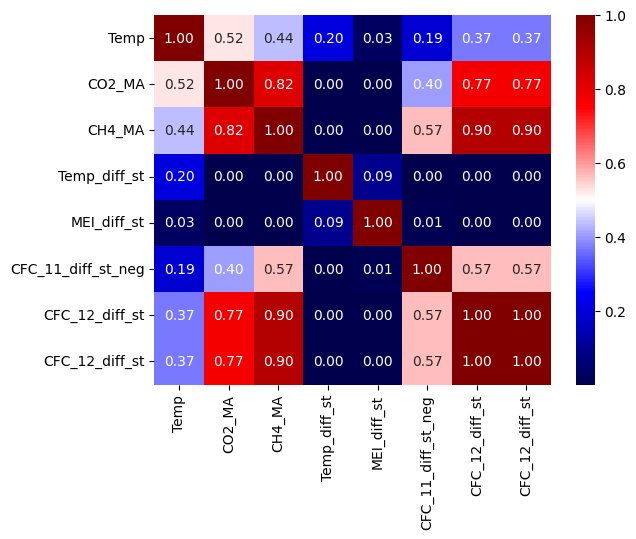

In [302]:
import seaborn as sns

r2_predictors = data[new_features].corr()**2
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

ValueError: not enough values to unpack (expected 2, got 1)

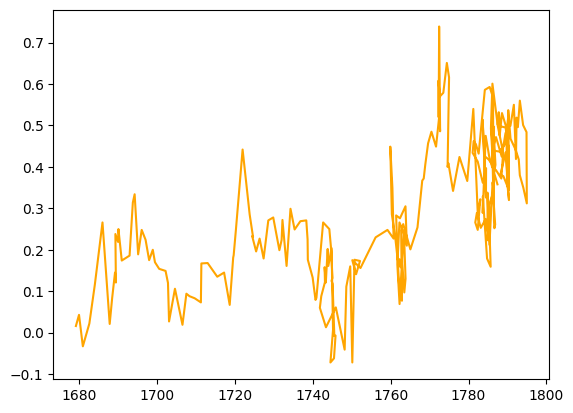

In [296]:
fig,axes = plt.plot(data['CH4_MA'],data['Temp'],color='orange')

figure out best shift for CO2

Providing 2 ways of encoding seasons: 
- by 3-month quarters (`season`) then one-hot encoding
- via cyclical encoding (`sea_cyc`), alr encoded but more granular version of `season`

In [ ]:
#dictionary for mapping month to season
season_mappings = [
    ([1, 2, 12], 'winter'),
    ([3, 4, 5], 'spring'),
    ([6, 7, 8], 'summer'),
    ([9, 10, 11], 'autumn')]

seasons_dict = {
    month: season
    for months, season in season_mappings
    for month in months}

# Create a new 'seasons' column in the DataFrame
data['seasons'] = data['Month'].astype(int).map(seasons_dict)
one_hot_seasons = pd.get_dummies(data[['seasons']])
# Display the first few rows to verify
data = data.join(one_hot_seasons)

# add cyclical encoding for months
def encode(data, col, max_val):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col]/max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col]/max_val)
    return data

data = encode(data, 'Month', 12)

data.loc[:,~data.columns.duplicated()]
print(data.head(1))


   Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
0  1983    5.0  2.556  345.96  1638.59   L  191.324  350.113   M        H   

   ...  CFC_12_change  Temp_MA  Temp_diff  seasons  seasons_autumn  \
0  ...            NaN      NaN        NaN   spring           False   

   seasons_spring  seasons_summer  seasons_winter  Month_sin  Month_cos  
0            True           False           False        0.5  -0.866025  

[1 rows x 32 columns]


In [ ]:
cat_cols = ['TSI','N2O','Aerosols']
cat_rows = ['Low','Medium','High']
cat_enums = ['L','M','H']
cat_rows_sort = ['2_High','0_Low','1_Medium']

TSI_freq = data['TSI'].value_counts().sort_values()
N2O_freq = data['N2O'].value_counts()
SOL_freq = data['Aerosols'].value_counts()

cat_freq = pd.concat([TSI_freq,N2O_freq,SOL_freq],axis=1).copy()
cat_freq.columns = cat_cols

# sorting the index without using methods
cat_freq.index = cat_rows_sort
cat_freq.sort_index(inplace=True)
cat_freq.index = cat_rows
print("Frequency of categorical values in each category:")
print()
print(cat_freq)

Frequency of categorical values in each category:

        TSI    N2O  Aerosols
Low      90  294.0       109
Medium  160    NaN       141
High     52    8.0        52


<span style="color:LightSkyBlue">

Next, we will visualise and annotate a graph to get a graphical understanding of the data:
</span>

In [ ]:
#get categorical features in a list
categorical_features = datatypes[datatypes=="object"].index

exclude = ['N2O']

mask = datatypes.reindex(data.dtypes.index) == "object"
cat_features_selected = list(data.dtypes[mask].index)
season_values = ['seasons_autumn','seasons_spring','seasons_summer','seasons_winter']

# lazy filtering, removes N2O and other unwanted categorical variables, modifies references to encoded ones from part 1
cat_features_selected_u = list(i for i in cat_features_selected if i not in exclude) # use this to refer to raw categorical variable values
cat_features_selected = [str(i)+'_ord' for i in cat_features_selected if i not in exclude] + season_values # use this to refer to raw categorical variable values

print("Categorical features remaining:")
print(', '.join(cat_features_selected_u))

Categorical features remaining:
TSI, Aerosols, seasons


In [ ]:
print("Categorical features selected (encoded form):")
print(', '.join(cat_features_selected))

Categorical features selected (encoded form):
TSI_ord, Aerosols_ord, seasons_ord, seasons_autumn, seasons_spring, seasons_summer, seasons_winter


<span style="color:LightSkyBlue">

## **Feature Selection for numerical variables**

<span style="color:LightSkyBlue">

For numerical variables, we first investigated the distribution of each variable by plotting bargraphs as shown below.

In [4]:
# confirm the numerical variables we are working with
datatypes = data.dtypes
numerical_features = datatypes[datatypes!="object"].index
season_values = ['seasons_autumn','seasons_spring','seasons_summer','seasons_winter']
cat_encoded = {'Aerosols_ord', 'N2O_ord', 'TSI_ord'} | set(season_values) | {'Month_sin','Month_cos'} | {'seasons'}# set of categorical variables that have been encoded

numerical_features = list(set(numerical_features) - cat_encoded)
print(f"we are handling the following {len(numerical_features)} numerical features:")
print(numerical_features)

we are handling the following 9 numerical features:
['continuous_months', 'CH4', 'CFC-12', 'CFC-11', 'Temp', 'Year', 'Month', 'CO2', 'MEI']


In [ ]:
#print(numerical_features)
#plot_relevant_visualisations('MEI',data)
#plot_relevant_visualisations('CO2',data)
plot_relevant_visualisations('CH4',data)
#plot_relevant_visualisations('CFC-11',data)
#plot_relevant_visualisations('CFC-12',data)
#plot_relevant_visualisations('Temp',data)
#plot_categorical('N2O',data)
#plot_categorical('TSI',data)
#plot_categorical('Aerosols',data)

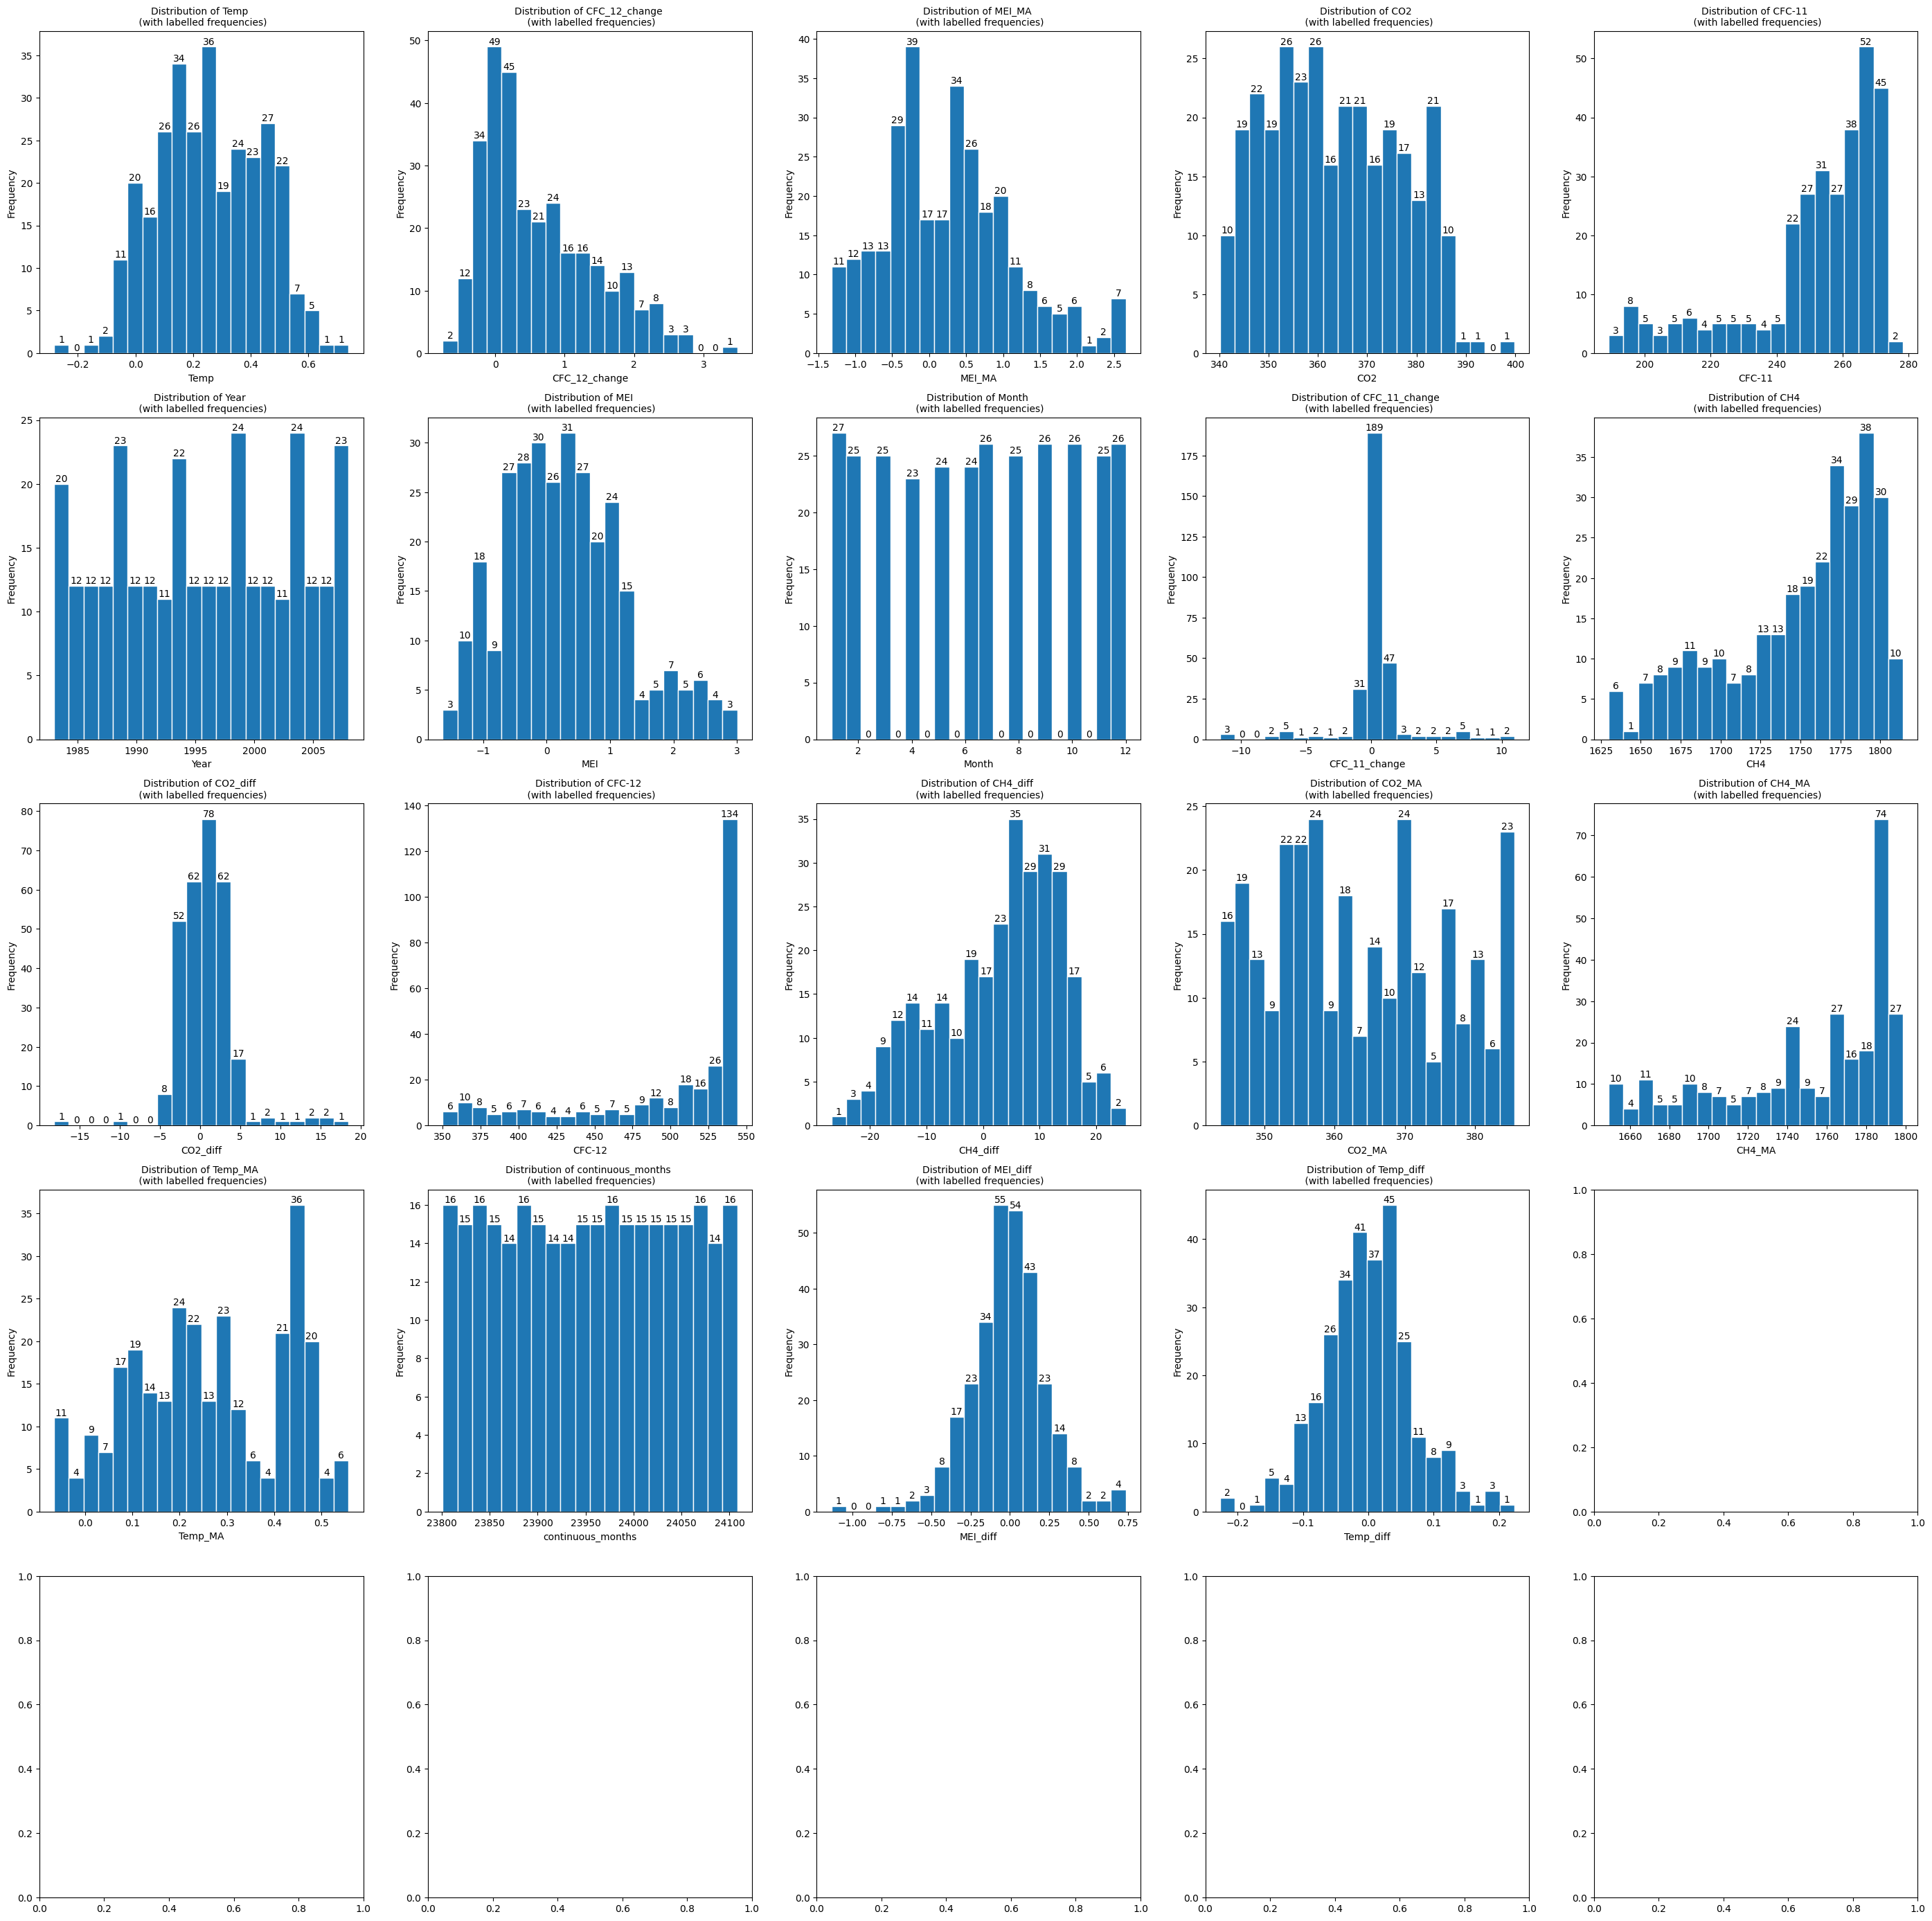

In [ ]:
# function to plot data
def print_histogram(data,num_features):
    
    y = 1
    x = len(num_features)
    # calculate best integer to get a square grid
    while x > (y ** 2):
        y += 1
    
    # set graph layout parameters
    SCALE_FACTOR = 5 # size of each plot
    plot_h,plot_w = y,y # how many columns of plots

    # set figure dimensions and subplot layout
    fig,axes = plt.subplots(plot_h,plot_w,figsize=((SCALE_FACTOR+2)*plot_w,(SCALE_FACTOR+2)*plot_h))

    n = len(num_features)

    for i in range(n):
        feature = num_features[i]
        ax = plt.subplot(plot_h,plot_w,i+1)
        freq, bins, patches = ax.hist(data[feature],bins=20,edgecolor='white')
        bin_centers = np.diff(bins)*0.5 + bins[:-1]
        
        h = 0
        for fr, x, patch in zip(freq, bin_centers, patches):
            height = int(freq[h])
            ax.annotate("{}".format(height),
                        xy = (x, height),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            h = h+1

        ax.set_title(f"Distribution of {feature} \n (with labelled frequencies)", fontsize=10)
        ax.set_xlabel(feature, fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
    plt.show()

print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

Based on a visual observation we noted the following:
- The variable `Year`, `month` and `continuous_months` are either used to build (or can themselves operate as) an index for each row. However, it may be useful since the atmospheric temperature may be related to variables that aren't recorded in our dataset but change over time such as `<FIND REASON>`, thus making it significant. furthermore, `continuous_months` makes more sense to retain because it represents a continuous flow of time rather than the `Year` and `Month` variables, thus we will likely not select the latter two as features.
- Given that `CFC-11` and `CFC-12` are somewhat similar since they are both chloroflourocarbons, we could consider creating a new feature that groups them together in some way.
- `CFC-12` and `CFC-11` each are highly skewed values. We will likely need to perform a log transformation to mitigate the effect of its skewness. (to assess how significant doing this is, we will simply compare visually using a quartile-quartile plot of a normal distribution how significant this transformation is.)

### TODO: replace the `<FIND REASONS>` with meaningful research. I leave its complexity to your discretion. ps: reasoning for including Continuous_months kinda iffy, help justify if not remove

<span style="color:LightSkyBlue">

Thus, we will do the following for numerical feature selection:
1. Exclude the `Year` and `Month` variable from our selected features
2. Find a suitable combination of `CFC-12` and `CFC-11` and use that as a feature instead
3. Visualise the $r^2$ values of each pair of variables, and assess which are relevant to retain
4. Perform a log transformation to all skewed variables (`MEI`,`CH4`, and likely the new combined CFC feature.)

<span style="color:LightSkyBlue">

1.  remove the features `Year` and `Month` from our numerical features

<span style="color:LightSkyBlue">

2. Create variations of combining `CFC-11` and `CFC-12`, naming the variable `CFC_<op>` based on the operation performed.

In [ ]:
# new feature: CFC_add = "CFC-11" + "CFC-12"
if 'CFC_add' not in numerical_features:
    data['CFC_add'] = data['CFC-12'] + data['CFC-11']
    numerical_features.append('CFC_add')

#new feature: CFC_times = "CFC-11" * "CFC-12"
if 'CFC_times' not in numerical_features:
    data['CFC_times'] = data['CFC-11'] * data['CFC-12']
    numerical_features.append('CFC_times')
    
# if cell was run multiple times, this line makes sure there are no duplicates
data.loc[:,~data.columns.duplicated()]
print(f"we are now handling the following {len(numerical_features)} numerical features:")
for i in numerical_features:
    print(i)

we are now handling the following 21 numerical features:
Temp
CFC_12_change
MEI_MA
CO2
CFC-11
Year
MEI
Month
CFC_11_change
CH4
CO2_diff
CFC-12
CH4_diff
CO2_MA
CH4_MA
Temp_MA
continuous_months
MEI_diff
Temp_diff
CFC_add
CFC_times


<span style="color:LightSkyBlue">

we can visualise this new set of features using the `print_historgram` function from above:

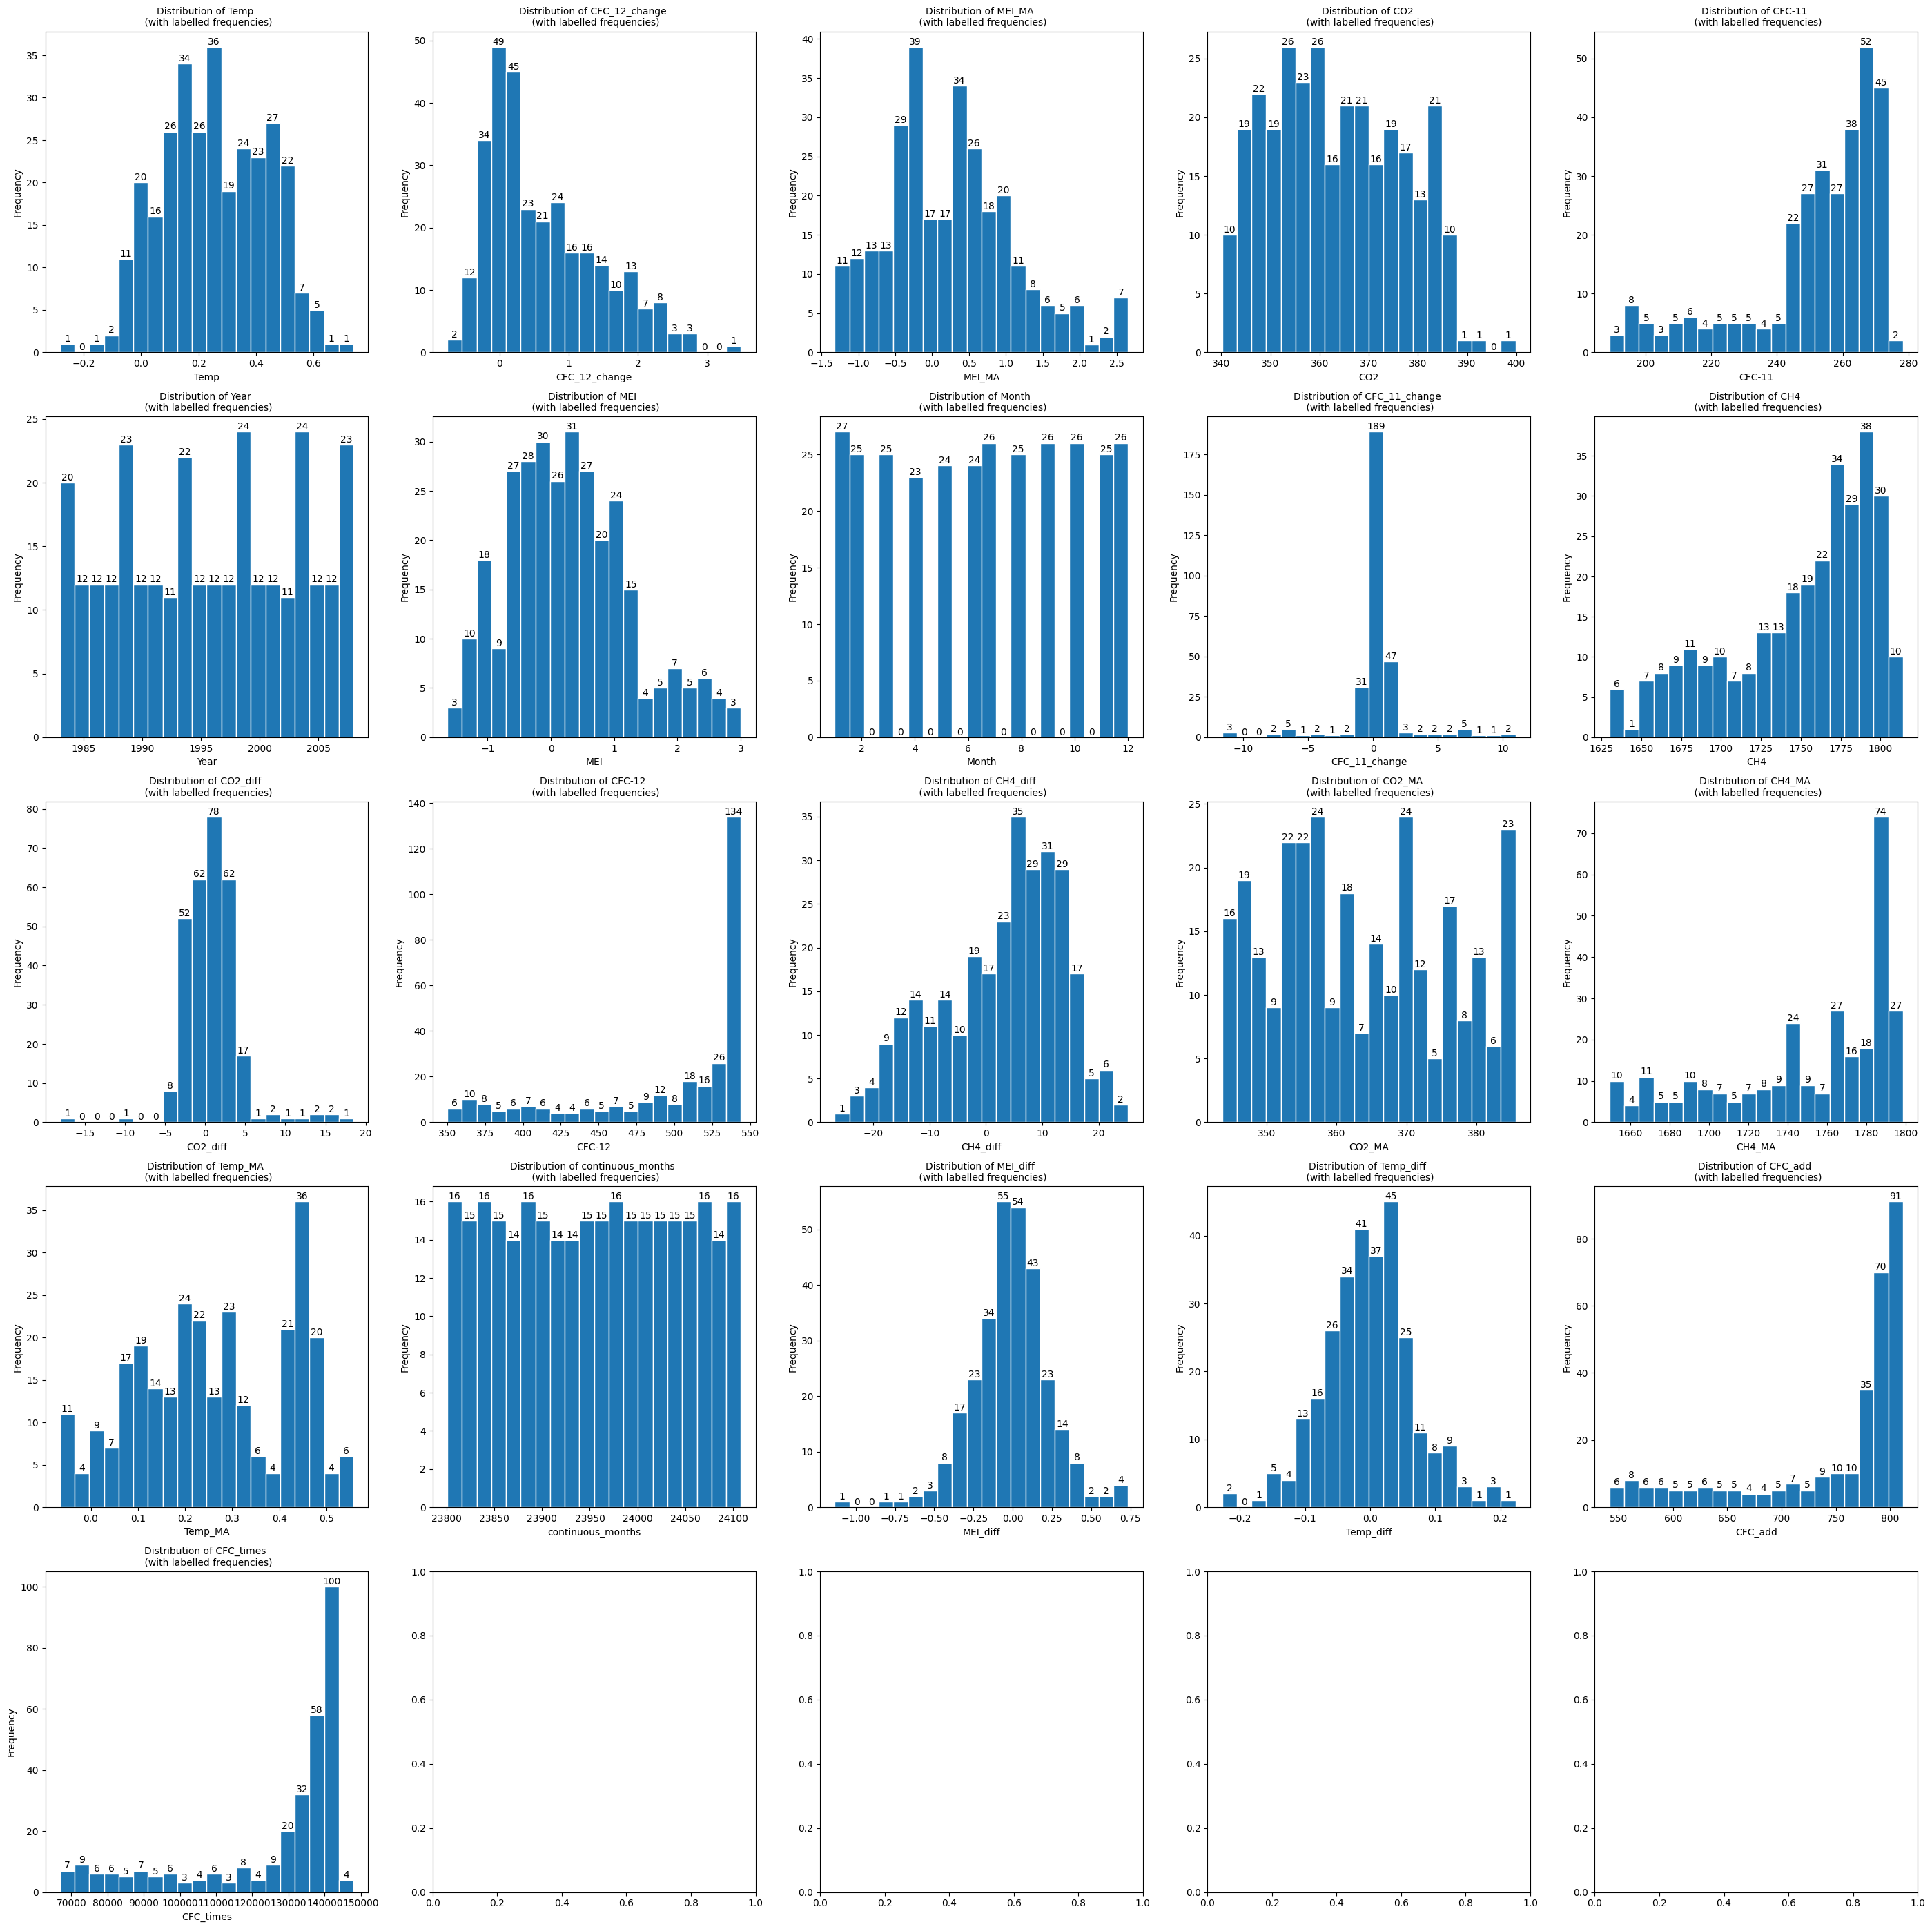

In [ ]:
print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

As many of the features (namely, `MEI`,`CH4`, `CFC-11`, `CFC-12`, `CFC_add` and `CFC_times`) are highly skewed, we can use either:
- a power transformer and perform the yeo-johnson transformation to apply non-linear transformations to enable our data to better resemble a normal distribution;
- a quantile transformer, which will provide non-linear transformations to 

In [ ]:
from sklearn.preprocessing import QuantileTransformer

#ensure duplicate rows are not created from running this cell multiple times
data.loc[:,~data.columns.duplicated()]

qt = QuantileTransformer(output_distribution='normal', random_state=42,n_quantiles=302)

data['CFC_add_norm'] = qt.fit_transform(data[['CFC_add']])
data['CFC_times_norm'] = qt.fit_transform(data[['CFC_times']])
data['CFC_11_norm'] = qt.fit_transform(data[['CFC-11']])
data['CFC_12_norm'] = qt.fit_transform(data[['CFC-12']])
data['CH4_norm'] = qt.fit_transform(data[['CH4']])
data['MEI_norm'] = qt.fit_transform(data[['MEI']])

numerical_features = numerical_features + [
    'CFC_add_norm',
'CFC_times_norm',
'CFC_11_norm',
'CFC_12_norm',
'CH4_norm',
'MEI_norm'
]

we will also standardise the following features:
- CFC_11_change
- CFC_12_change
- CH4_diff
- CO2+_diff

In [ ]:
for i in numerical_features:
    print(i)

Temp
CFC_12_change
MEI_MA
CO2
CFC-11
Year
MEI
Month
CFC_11_change
CH4
CO2_diff
CFC-12
CH4_diff
CO2_MA
CH4_MA
Temp_MA
continuous_months
MEI_diff
Temp_diff
CFC_add
CFC_times
CFC_add_norm
CFC_times_norm
CFC_11_norm
CFC_12_norm
CH4_norm
MEI_norm


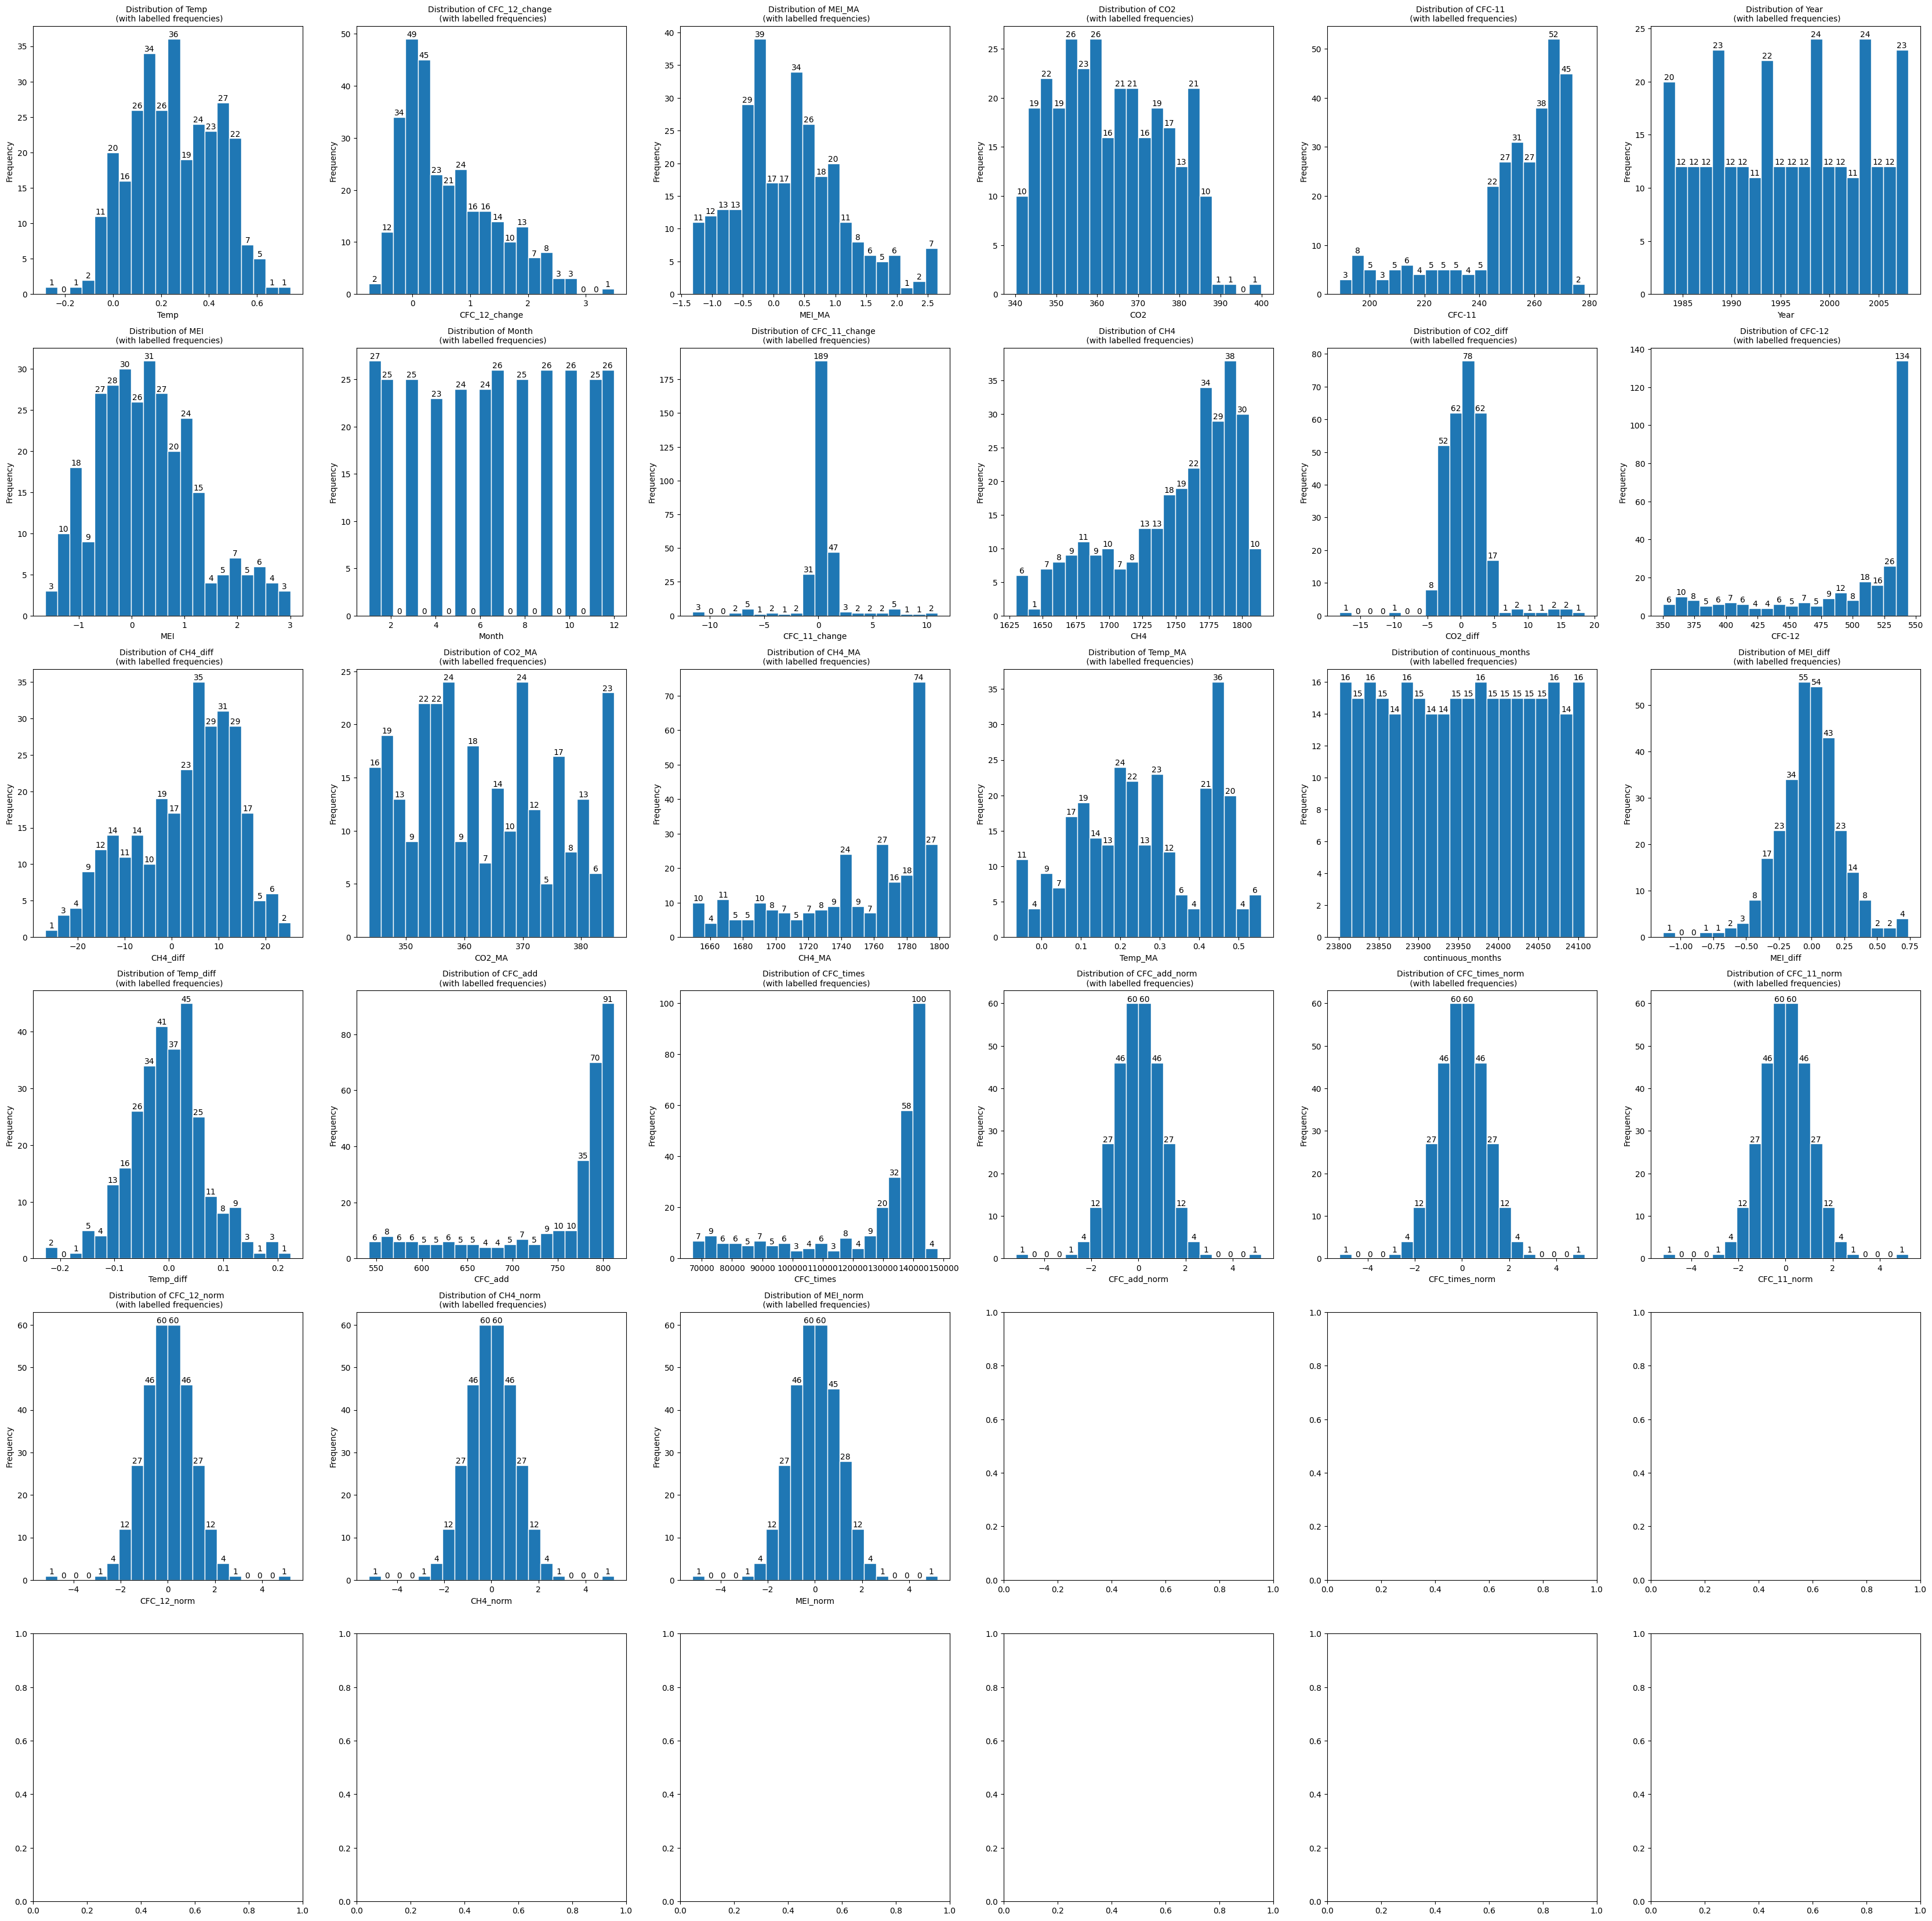

In [ ]:
print_histogram(data,numerical_features)

In [ ]:
# use standardised temp
from sklearn.preprocessing import StandardScaler

preprocess = [
'CFC_11_change',
'CFC_12_change',
'MEI_diff',
'CO2_diff',
'CH4_diff',
'Temp',
'Temp_diff'
]

for i in preprocess:
    data[i+"_st"] = StandardScaler().fit_transform(data[[i]])
    numerical_features.append(i+'_st')
    
data.loc[:,~data.columns.duplicated()]

#numerical_features.remove('Temp') if 'Temp' in numerical_features else None

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,...,CFC_12_norm,CH4_norm,MEI_norm,CFC_11_change_st,CFC_12_change_st,MEI_diff_st,CO2_diff_st,CH4_diff_st,Temp_st,Temp_diff_st
0,1983,5.0,2.556,345.96,1638.59,L,191.324,350.113,M,H,...,-5.199338,-2.129383,2.055123,NaN,NaN,NaN,NaN,NaN,-0.832828,NaN
1,1983,6.0,2.167,345.52,1633.71,L,192.057,351.848,M,H,...,-2.714154,-2.327596,1.646466,0.226227,1.393342,NaN,NaN,NaN,-0.782381,NaN
2,1983,7.0,1.741,344.15,1633.22,L,189.051,353.725,M,H,...,-2.475928,-2.475928,1.342599,-1.350925,1.569881,NaN,NaN,NaN,-0.675880,NaN
3,1983,8.0,1.130,342.25,1631.35,L,193.602,355.633,M,H,...,-2.327596,-2.714154,0.983053,1.836701,1.608421,NaN,NaN,NaN,-0.457275,NaN
4,1983,9.0,0.428,340.17,1648.40,L,194.392,357.465,M,H,...,-2.217659,-1.990720,0.239612,0.250270,1.513935,NaN,NaN,NaN,-0.608617,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,2008,8.0,-0.266,384.15,1779.88,L,244.200,535.072,L,L,...,0.196966,0.433775,-0.517724,-0.181665,-0.706478,0.253074,-0.469585,-1.767842,0.837542,NaN
298,2008,9.0,-0.643,383.09,1795.08,L,244.083,535.048,L,M,...,0.188483,1.082411,-1.052961,-0.132313,-0.793505,-2.485189,-0.833061,-0.376212,0.674990,NaN
299,2008,10.0,-0.780,382.99,1814.18,L,244.080,534.927,L,M,...,0.163110,5.199338,-1.210952,-0.084226,-0.914098,-4.669855,-0.907414,1.290401,1.022516,NaN
300,2008,11.0,1.345,384.13,1812.37,L,244.225,534.906,L,M,...,0.154676,2.475928,1.210952,-0.021798,-0.789775,NaN,-0.615610,1.058118,0.764674,NaN


<span style="color:LightSkyBlue">

Next, we can assess a heat map of the correlation values of this new set of features.

In [ ]:
import seaborn as sns
#datatset_correlations = data[numerical_features].corr()
#r2 = data[numerical_features].corr()**2
r2 = dataV2[use_features].corr()**2
plt.figure(figsize=(36, 30))
sns.heatmap(r2, annot=True, fmt='.2f', cmap='seismic')
plt.title('Heatmap of correlation values among selected features')
plt.show()

NameError: name 'dataV2' is not defined

<span style="color:LightSkyBlue">

Before we perform a log transformation of our data, we will prematurely assess whether the dependent variable `Temp` is correlated with our independent variables. We could do it with a correlation table or via correlation heatmap as above.  As prescribed in lab3, we have plot our correlation heatmap using the $r^2$ values instead, where the closer each value is to 0, the more 'blue' a cell will be and the less related each value will be. 

3. Referencing the above heatmap, we will be pruning these highly-uncorrelated features. However, we will lower the threshold than what was prescribed in lab3 as most of the features have $r^2$ values that hover slightly below the 0.5 threshold, thus we will change it to 0.45.

In [ ]:

def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

numerical_features_selected = corr_features(data[use_features], 'Temp', 0.5)
print(f"updated selected features: {numerical_features_selected}")

KeyError: 'Temp'

<span style="color:LightSkyBlue">

We will also remove any features that are too correlated to each other, since it means that we can further reduce the number of dimensions that our data has. This renders the following benefits: 
- Our model performance will likely be higher
- Model training and inference will be faster since less data is involved
- The model has a lower chance of overfitting

However, removing too many features may have the opposite effect of making our model less accurate, thus we will retain at least 3 features, and set our threshold $r^2$ value for removing features to be 0.9.

<span style="color:LightSkyBlue">

First, lets visualise the correlation map of currently selected features:

In [ ]:
r2_predictors = data[numerical_features_selected].corr()**2
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

NameError: name 'data' is not defined

<span style="color:LightSkyBlue">

Next, lets remove the highly correlated features. 

In [ ]:
# get the feature that has the most number of features
# it is correlated with, beyond certain threshold

def most_corr_feature(df, threshold):
    r2_matrix = abs(df.corr()**2)
    count = r2_matrix[r2_matrix>threshold].count()
    return count.sort_values(ascending=False).index[0]

# return true if all the features are uncorrelated,
# as defined by a threshold

def all_features_uncorr(df, threshold):
    r2_matrix = abs(df.corr()**2)
    n = len(r2_matrix)
    
    # checks for any pair of variables with r^2 value higher than threshold
    return r2_matrix[r2_matrix>threshold].count().sum()==n

# get a set of uncorrelated features
def get_uncorr_features(df, threshold,min_features=0):
    features = df.columns.tolist()
    while all_features_uncorr(df[features], threshold) == False and len(features)> min_features:
        most_corr_fea = most_corr_feature(df[features], threshold)
        features.remove(most_corr_fea)
    return features

In [ ]:
numerical_features_selectedV2 =[i for i in numerical_features_selected if i != 'Temp']

numerical_features_selectedV2 = get_uncorr_features(data[numerical_features_selectedV2], 0.8,min_features=0)
print(f"Selected numerical features : {numerical_features_selectedV2}")

Selected numerical features : ['CO2', 'CFC_times', 'CFC_add_norm', 'CFC_12_norm', 'CH4_norm']


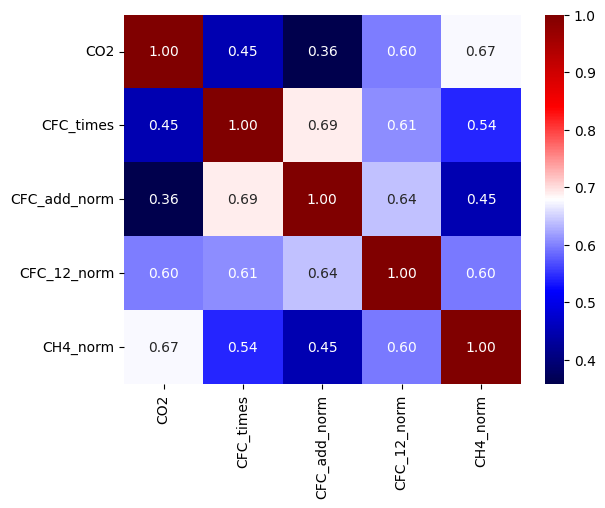

In [ ]:
numerical_features_selected = numerical_features_selectedV2.copy()
r2_predictors = data[numerical_features_selected].corr()**2
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

<span style="color:LightSkyBlue">

4. Lastly, we will transform the features that do not look like any typical distributions (ie. the normal distribution). We will save variations of these sets of transformed features and see if the transformed data will yield better predictions when we create our model later.

<span style="color:LightSkyBlue">
First, we will visualise the selected features thus far:

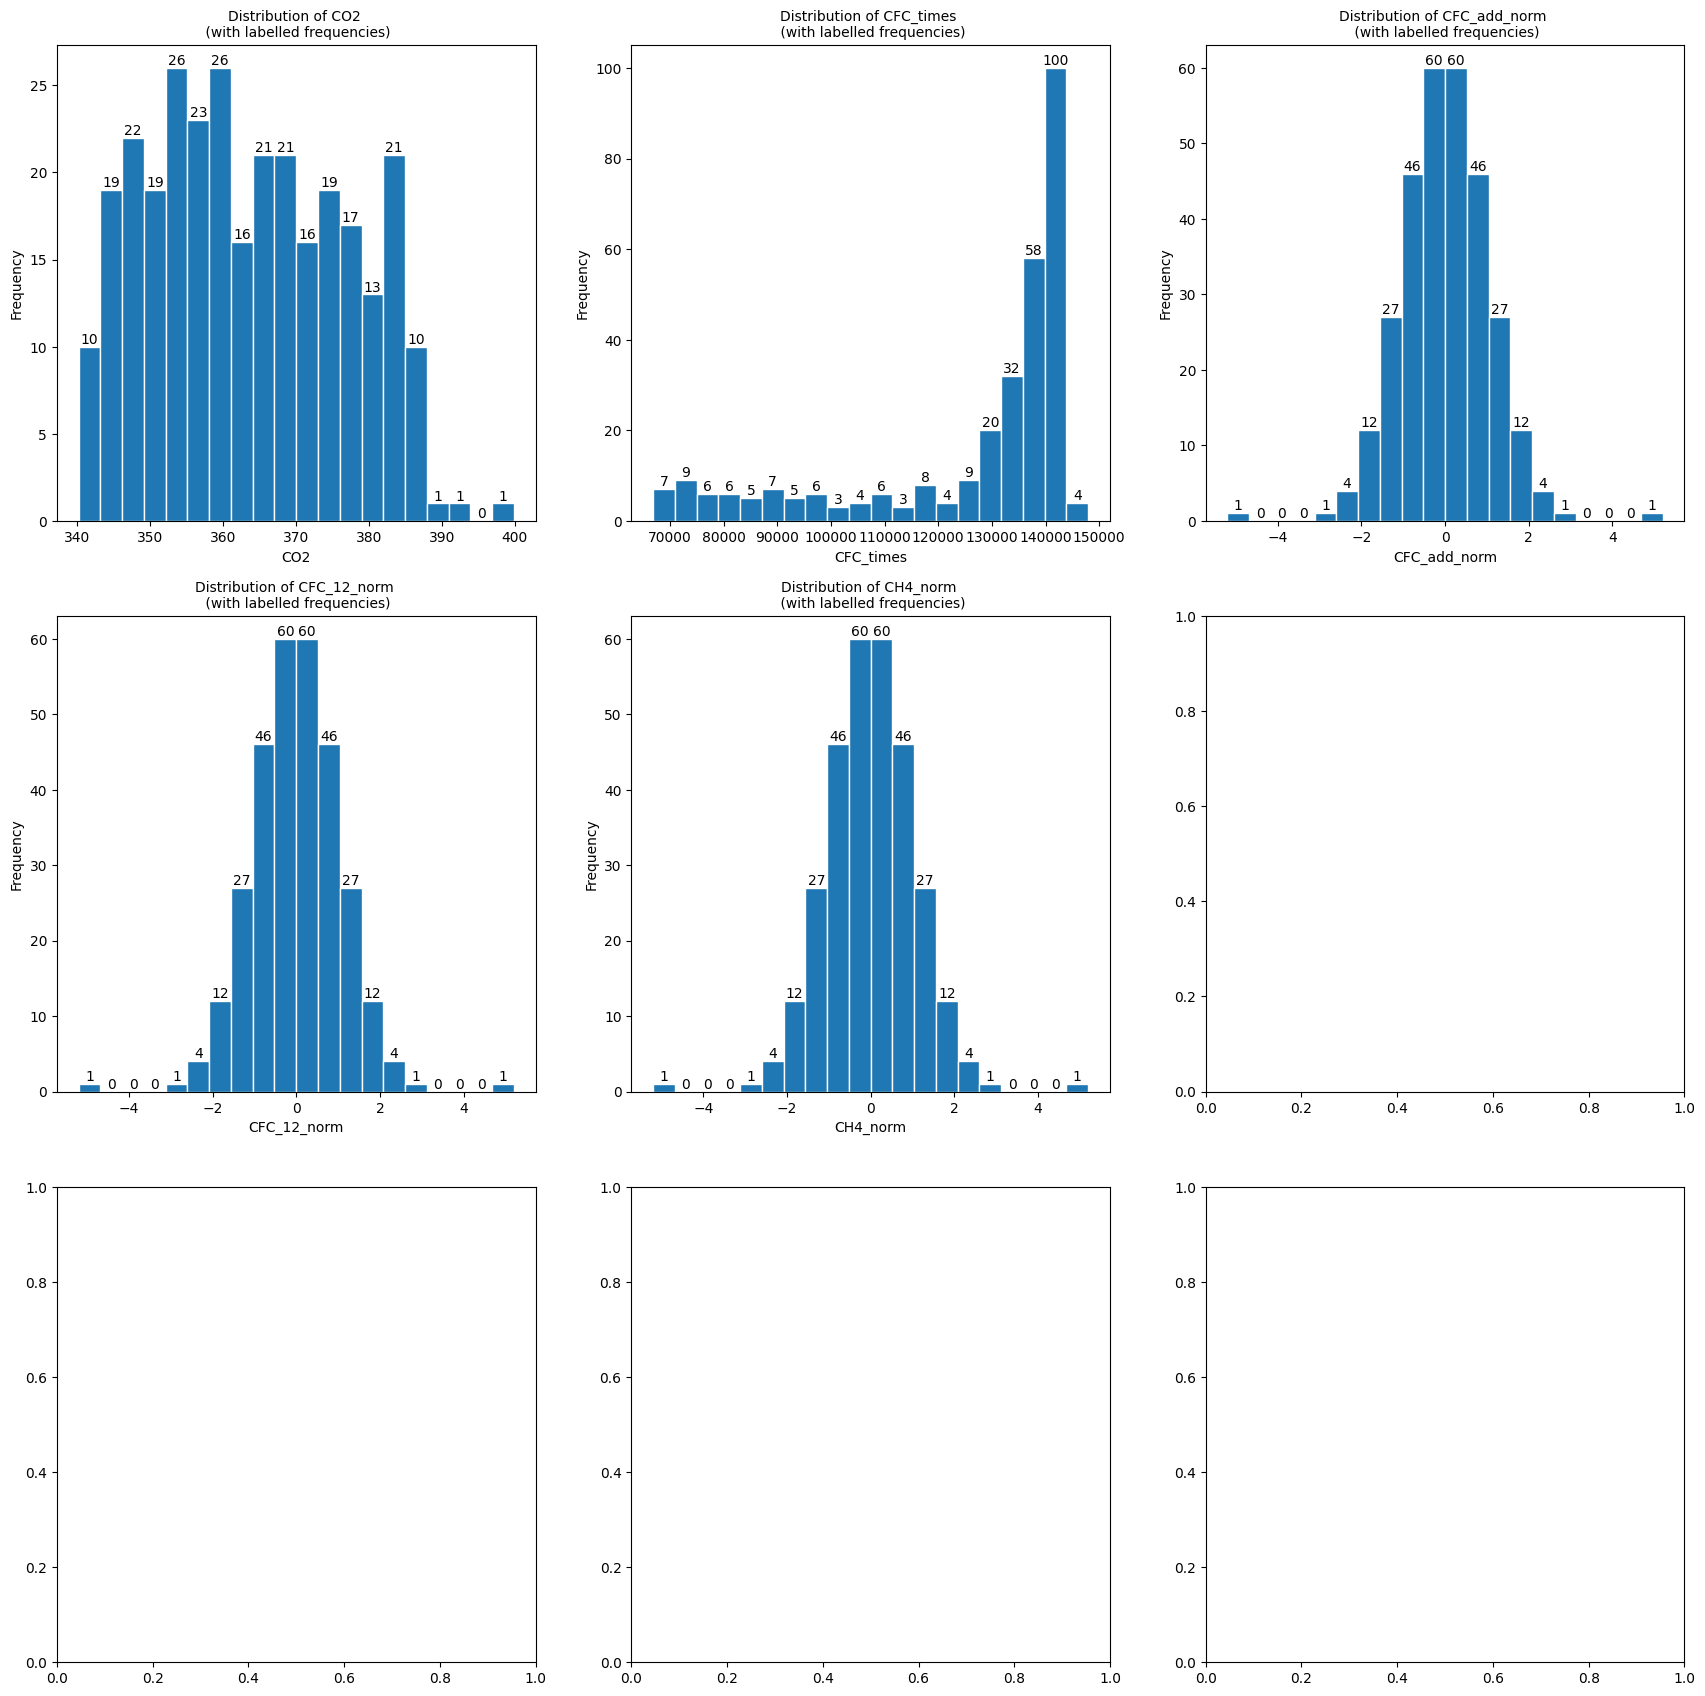

In [ ]:
print_histogram(data,numerical_features_selected)

In [ ]:
numerical_features_selected = list(set(numerical_features_selected) - {'Temp'})
print(numerical_features_selected)

['CFC_12_norm', 'CFC_times', 'CO2', 'CFC_add_norm', 'CH4_norm']


In [ ]:
# tf1 -- transform CH4 to log scale
numerical_features_selected_tf1 = numerical_features_selected.copy()
data['CFC_times_lg'] = np.log(data['CFC_times'])

numerical_features_selected_tf1.append('CFC_times_lg')
numerical_features_selected_tf1.remove('CFC_times')

# tf1 -- transform CH4 to log scale
from sklearn.preprocessing import StandardScaler

numerical_features_selected_tf2 = numerical_features_selected.copy()
data['CFC_times_lg'] = np.log(data['CFC_times'])
data['CFC_times_lg_st'] = StandardScaler().fit_transform(data[['CFC_times_lg']])

numerical_features_selected_tf2.append('CFC_times_lg_st')
numerical_features_selected_tf2.remove('CFC_times')


#ensure no duplicate rows exist from multiple runs of this cell
data.loc[:,~data.columns.duplicated()]

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,...,CFC_times,CFC_add_norm,CFC_times_norm,CFC_11_norm,CFC_12_norm,CH4_norm,MEI_norm,Temp_st,CFC_times_lg,CFC_times_lg_st
0,1983,5.0,2.556,345.96,1638.59,L,191.324,350.113,M,H,...,66985.019612,-5.199338,-2.714154,-2.714154,-5.199338,-2.129383,2.055123,-0.832828,11.112224,-2.965052
1,1983,6.0,2.167,345.52,1633.71,L,192.057,351.848,M,H,...,67574.871336,-2.475928,-2.475928,-2.475928,-2.714154,-2.327596,1.646466,-0.782381,11.120991,-2.922758
2,1983,7.0,1.741,344.15,1633.22,L,189.051,353.725,M,H,...,66872.064975,-2.714154,-5.199338,-5.199338,-2.475928,-2.475928,1.342599,-0.675880,11.110537,-2.973194
3,1983,8.0,1.130,342.25,1631.35,L,193.602,355.633,M,H,...,68851.260066,-2.327596,-2.327596,-2.327596,-2.327596,-2.714154,0.983053,-0.457275,11.139704,-2.832486
4,1983,9.0,0.428,340.17,1648.40,L,194.392,357.465,M,H,...,69488.336280,-2.217659,-2.217659,-2.217659,-2.217659,-1.990720,0.239612,-0.608617,11.148914,-2.788053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,2008,8.0,-0.266,384.15,1779.88,L,244.200,535.072,L,L,...,130664.582400,-0.300075,-0.452147,-0.832165,0.196966,0.433775,-0.517724,0.837542,11.780389,0.258302
298,2008,9.0,-0.643,383.09,1795.08,L,244.083,535.048,L,M,...,130596.120984,-0.313168,-0.470674,-0.843997,0.188483,1.082411,-1.052961,0.674990,11.779865,0.255774
299,2008,10.0,-0.780,382.99,1814.18,L,244.080,534.927,L,M,...,130564.982160,-0.335111,-0.489363,-0.855948,0.163110,5.199338,-1.210952,1.022516,11.779626,0.254623
300,2008,11.0,1.345,384.13,1812.37,L,244.225,534.906,L,M,...,130637.417850,-0.313168,-0.461391,-0.820449,0.154676,2.475928,1.210952,0.764674,11.780181,0.257299


3 versions of our features have been made:
- `numerical_features_selected` --- The untransformed features that have met our criteria for correlation values 
- `numerical_features_selected_tf1` --- `CFC_add` was log-transformed and renamed `CFC_add_lg`
- `numerical_features_selected_tf2` --- `CH4` was log-transformed and renamed `CH4_lg`
- `numerical_features_selected_tf3` --- `CFC_add` was transformed to resemble a normal distribution using Scikit learn's `quantile transformer` function, and renamed `CFC_add_norm`.

<span style="color:LightSkyBlue">

# TODO: Wei Bin i have no idea how to fit this in, please help

Based on the correlation analysis and heatmap visualization, I have selected the following numerical variables for predicting temperature:

**Primary Features (Strong Correlations):**
1. CO2 (correlation = 0.71)
   - Strongest correlation with temperature among all variables
   - Key greenhouse gas with direct physical relationship to global warming
   - Shows consistent positive trend with temperature

2. CH4 (correlation = 0.69)
   - Strong positive correlation with temperature
   - Known potent greenhouse gas (28 times more potent than CO2)
   - Provides complementary information to CO2

3. CFC-12 (correlation = 0.69)
   - Strong correlation with temperature
   - Class 1 Ozone-depleting substance with high global warming potential
   - Important atmospheric indicator

**Features Excluded:**

1. CFC-11 (correlation = 0.66)
   - Despite moderate correlation with temperature, excluded due to very high multicollinearity with CFC-12 (0.98)
   - Including both CFC-11 and CFC-12 would introduce redundancy in the model
   - CFC-12 preferred due to its higher global warming potential

2. MEI (correlation = 0.14)
   - Very weak correlation with temperature
   - While it measures important climate phenomena (El Niño/La Niña), the low correlation suggests limited direct predictive value for temperature


**Justification:**
- Selection prioritizes variables with correlation coefficients > 0.65 with temperature
- Avoids multicollinearity by not including highly correlated predictor pairs
- Chosen variables have clear physical mechanisms linking them to temperature changes
- Selected features represent different aspects of atmospheric composition affecting global temperature

<span style="color:LightSkyBlue">

# TODO: Wei Bin i have no idea how to fit this in, please help

### Removal of selected features that are correlated to each other

Looking at the correlation heatmap:

CO2 with CH4: correlation = 0.94  
CO2 with CFC-12: correlation = 0.96  
CH4 with CFC-12: correlation = 0.91  

This reveals a significant issue: all three of our selected features are highly correlated with each other (correlation coefficients > 0.90). This indicates strong multicollinearity, which means these variables are indeed redundant with each other.
Given this high multicollinearity, we should revise our feature selection. Here's how we should proceed:
Since CO2 has the highest correlation with temperature (0.71), we should keep it as our primary feature.
We should exclude CH4 and CFC-12 despite their strong correlations with temperature because:
They are highly correlated with CO2 (0.94 and 0.96 respectively)
Including them would introduce redundancy in our model

Their relationships with temperature might be captured indirectly through CO2

lastly, we will combine the features that we have selected from the pool of categorical and numerical variables.

In [ ]:
features_selected = cat_features_selected + numerical_features_selected_tf2
print(", ".join(features_selected))

TSI_ord, Aerosols_ord, CFC_12_norm, CO2, CFC_add_norm, CH4_norm, CFC_times_lg_st


**b.** Split the dataset into train and test sets. Describe how you split step by step.

**Response.** 

We will use the prescribed method from lab3, and split the data using the function under the sci-kit learn library `train_test_split` for splitting our data. We will also be performing an 80-20 test-train split as prescribed for many model training techniques.

In [ ]:
from sklearn.model_selection import train_test_split

#features_selected = ['Aerosols_ord' ,'CO2','CFC-11' ,'CFC-12']
X = data[features_selected]
y = data[["Temp"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

**c.** State the model(s) you will train, and explain your choice(s), in **no more than 50 words per model**. You only need to
train one model, but if you do train more models, limit yourself to no more than three---Grading is based on the validity and soundness of your model, rather than the quantity.

**Response.** 

**Models Selected:**

1. Linear regression
2. Elastic Net Regression with Cross validation
3. 



**d.** For each model, perform the training, and report the trained parameters and the training scores, if applicable. 

**Response.** 

In [ ]:
## model fitting for linear regression

from sklearn.linear_model import LinearRegression

model1 = LinearRegression().fit(X_train, y_train)
model1_r2 = model1.score(X_train, y_train)
model1_r2_val = model1.score(X_test, y_test)
coef1 = model1.coef_
bias1 = model1.intercept_

print("Model 1: Linear Regression ")
print("--------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef1[0]}")
print(f"Intercept : {bias1[0]}")
print(f"Coeff of Determination : {model1_r2}")
print(f"Coeff of Determination (on validation set): {model1_r2_val}")

Model 1: Linear Regression 
--------------------------
Features : ['TSI_ord', 'Aerosols_ord', 'CFC_12_norm', 'CO2', 'CFC_add_norm', 'CH4_norm', 'CFC_times_lg_st']
Coefficients: [ 0.0370158  -0.04803106  0.06401515  0.00462796 -0.04561832 -0.00354427
  0.0224663 ]
Intercept : -1.417938376984387
Coeff of Determination : 0.6602953992385063
Coeff of Determination (on validation set): 0.5777173079478543


In [ ]:
## model fitting for ridge

from sklearn.ensemble import GradientBoostingRegressor

model2 = GradientBoostingRegressor().fit(X_train, y_train)
model2_r2 = model2.score(X_train, y_train)
model2_r2_val = model2.score(X_test, y_test)
#coef2 = model2.coef_
#bias2 = model2.intercept_
#print(bias2)

print("Model 2: Ridge Regression")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
#print(f"Coefficients: {coef2[0]}")
#print(f"Intercept : {bias2}")
#print(f"Intercept : {bias2[0]}")
print(f"Coeff of Determination : {model2_r2}")
print(f"Coeff of Determination (on validation set): {model2_r2_val}")

Model 2: Ridge Regression
-------------------------
Features : ['TSI_ord', 'Aerosols_ord', 'CFC_12_norm', 'CO2', 'CFC_add_norm', 'CH4_norm', 'CFC_times_lg_st']
Coeff of Determination : 0.996279310271503
Coeff of Determination (on validation set): 0.6869412443188221


c:\Users\ChunChunMaru\anaconda3\envs\QNN\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [ ]:
## model fitting for ridge
from sklearn.svm import LinearSVR

model3 = LinearSVR().fit(X_train, y_train)
model3_r2 = model3.score(X_train, y_train)
model3_r2_val = model3.score(X_test, y_test)
coef3 = model3.coef_
bias3 = model3.intercept_

print("Model 2: Ridge Regression")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef3}")
#print(f"Coefficients: {coef3[0]}")
print(f"Intercept : {bias3[0]}")
print(f"Coeff of Determination : {model3_r2}")
print(f"Coeff of Determination (on validation dataset): {model3_r2}")

Model 2: Ridge Regression
-------------------------
Features : ['TSI_ord', 'Aerosols_ord', 'CFC_12_norm', 'CO2', 'CFC_add_norm', 'CH4_norm', 'CFC_times_lg']
Coefficients: [ 1.01545680e-01 -1.97090191e-01  2.42336928e-01  1.41932966e-04
  8.21189042e-02  2.18137019e-01 -1.17238920e-01]
Intercept : -0.012767084156902347
Coeff of Determination : -1.6754009971010793


c:\Users\ChunChunMaru\anaconda3\envs\QNN\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ChunChunMaru\anaconda3\envs\QNN\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### 3. Model evaluation and selection [30% of Part II]

**a.** For each model, predict the response variable on the test set.

**Response.** 

In [ ]:
## model 1 evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# predict based on test set
y_pred = model1.predict(X_test)

# compare with ground truth
mae = mean_absolute_error(y_test, y_pred)
ave = np.mean(y_test["Temp"])
rmse = root_mean_squared_error(y_test, y_pred)  # setting squared = False returns the square-root 




print("Model 1 Evaluation")
print("-----------------")
print(f"MAE: {mae:.2f}")
print(f"MAE as % of mean: {mae/ave*100:.1f}%")
print(f"RMSE: {rmse:.2f}")
print(f"RMSE as % of mean: {rmse/ave*100:.1f}%")

KeyError: 'Temp'

In [ ]:
## model 2 evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# predict based on test set
y_pred2 = model2.predict(X_test)

# compare with ground truth
mae2 = mean_absolute_error(y_test, y_pred2)
ave = np.mean(y_test["Temp"])
rmse2 = root_mean_squared_error(y_test, y_pred2)  # setting squared = False returns the square-root 

print("Model 2 Evaluation")
print("-----------------")
print(f"MAE: {mae2:.2f}")
print(f"MAE as % of mean: {mae2/ave*100:.1f}%")
print(f"RMSE: {rmse2:.2f}")
print(f"RMSE as % of mean: {rmse2/ave*100:.1f}%")

Model 2 Evaluation
-----------------
MAE: 0.09
MAE as % of mean: 37.7%
RMSE: 0.12
RMSE as % of mean: 50.6%


**b.** Describe the metric you use to evaluate your model(s). Report the test scores for each model.

**Response.** 

**c.** If you trained more than one model, identify the final model you would choose for the prediction task, and explain your choice, **in no more than 50 words**.

**Response.** 

### 4. Findings and conclusion [20% of Part II]

**a.** Interpret what your model is implying, and summarize any insight you have drawn from the project. Explain if it is consistent with intuition, and if not, provide a plausible justification. Limit your entire response to **50 words**.

**Response.** 

**b.** Share any lesson you have learned from the project, in **no more than 50 words**.

**Response.** 

### 5. Non-technical protocol [5% of Part II]

**a.** Describe the detailed contribution of each team member, including both the tangible (e.g., implementation, testing, writing) and intangible (e.g., generating ideas, planning, leadership) efforts.

**Response.** 

**b.** List any references and sources you have cited.

**Response.** 